In [1]:
# Importando librerias
import warnings
warnings.filterwarnings("ignore")      # oculta avisos técnicos para que la pantalla quede limpia

import numpy as np                     # cálculo numérico
import pandas as pd                    # tablas de datos
import matplotlib.pyplot as plt        # gráficas
import kagglehub                       # descarga datasets de Kaggle

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (classification_report, ConfusionMatrixDisplay, confusion_matrix,
                             accuracy_score, recall_score, precision_score, f1_score)

---
## 1 · Los datos

**Heart Failure Prediction Dataset** (fedesoriano, Kaggle): 918 pacientes de cinco cohortes cardiológicas.

| Variable | Significado clínico |
|---|---|
| `Age` | Edad (años) |
| `Sex` | Sexo (M / F) |
| `ChestPainType` | Dolor torácico: TA angina típica · ATA atípica · NAP no anginoso · ASY asintomático |
| `RestingBP` | Presión arterial sistólica en reposo (mm Hg) |
| `Cholesterol` | Colesterol sérico (mg/dL) |
| `FastingBS` | Glucosa en ayuno > 120 mg/dL (1 = sí) |
| `RestingECG` | ECG en reposo: Normal · ST (anomalía ST-T) · LVH (hipertrofia ventricular izquierda) |
| `MaxHR` | Frecuencia cardiaca máxima en prueba de esfuerzo |
| `ExerciseAngina` | Angina inducida por el ejercicio (Y / N) |
| `Oldpeak` | Depresión del segmento ST con el esfuerzo (mm) |
| `ST_Slope` | Pendiente del ST en el pico del esfuerzo: Up · Flat · Down |
| **`HeartDisease`** | **Lo que queremos predecir: 1 = con enfermedad cardiaca · 0 = sin enfermedad** |

In [2]:
# Importando datos
import kagglehub
from kagglehub import KaggleDatasetAdapter
df = kagglehub.dataset_load(KaggleDatasetAdapter.PANDAS,
                            "fedesoriano/heart-failure-prediction", "heart.csv")

In [3]:
# Explorando dataframe
df.head()

,Age,Sex,ChestPainType,RestingBP,Cholesterol,FastingBS,RestingECG,MaxHR,ExerciseAngina,Oldpeak,ST_Slope,HeartDisease
0,40,M,ATA,140,289,0,Normal,172,N,0.0,Up,0
1,49,F,NAP,160,180,0,Normal,156,N,1.0,Flat,1
2,37,M,ATA,130,283,0,ST,98,N,0.0,Up,0
3,48,F,ASY,138,214,0,Normal,108,Y,1.5,Flat,1
4,54,M,NAP,150,195,0,Normal,122,N,0.0,Up,0


In [4]:
# Imprimiendo renglones y columnas del dataframe
df.shape

(918, 12)

---
## Preparando  los datos



In [5]:
# Imprimiendo tipos de datos
df.dtypes

Age                 int64
Sex                   str
ChestPainType         str
RestingBP           int64
Cholesterol         int64
FastingBS           int64
RestingECG            str
MaxHR               int64
ExerciseAngina        str
Oldpeak           float64
ST_Slope              str
HeartDisease        int64
dtype: object

In [6]:
# Comprobando si existen datos nulos
df.isna().sum()

Age               0
Sex               0
ChestPainType     0
RestingBP         0
Cholesterol       0
FastingBS         0
RestingECG        0
MaxHR             0
ExerciseAngina    0
Oldpeak           0
ST_Slope          0
HeartDisease      0
dtype: int64

In [7]:
# Explorando los datos numéricos
df.describe().T

,count,mean,std,min,25%,50%,75%,max
Age,918.0,53.510893,9.432617,28.0,47.00,54.0,60.0,77.0
RestingBP,918.0,132.396514,18.514154,0.0,120.00,130.0,140.0,200.0
Cholesterol,918.0,198.799564,109.384145,0.0,173.25,223.0,267.0,603.0
FastingBS,918.0,0.233115,0.423046,0.0,0.00,0.0,0.0,1.0
MaxHR,918.0,136.809368,25.460334,60.0,120.00,138.0,156.0,202.0
Oldpeak,918.0,0.887364,1.066570,-2.6,0.00,0.6,1.5,6.2
HeartDisease,918.0,0.553377,0.497414,0.0,0.00,1.0,1.0,1.0


In [8]:
# Corrigiendo los valores numericos en 0 que no hacen sentido

df['Cholesterol'] = df['Cholesterol'].replace(0, np.nan)
df['RestingBP'] = df['RestingBP'].replace(0, np.nan)

In [9]:
# Validando la conversión a valores nulos
df.isna().sum()

Age                 0
Sex                 0
ChestPainType       0
RestingBP           1
Cholesterol       172
FastingBS           0
RestingECG          0
MaxHR               0
ExerciseAngina      0
Oldpeak             0
ST_Slope            0
HeartDisease        0
dtype: int64

# Dividiendiendo los Datos y Aplicando One Hot

In [10]:
# Separando los datos en x e y
y = df['HeartDisease']
X = df.drop(columns= ['HeartDisease'])

In [11]:
# Definiendo columnas de tipo caracter o string
string_columns = ['Sex','ChestPainType','RestingECG','ExerciseAngina','ST_Slope']

# Iterando sobre las columnas string
for column in string_columns:
    print(X[column].value_counts())
    print('\n')

Sex
M    725
F    193
Name: count, dtype: int64


ChestPainType
ASY    496
NAP    203
ATA    173
TA      46
Name: count, dtype: int64


RestingECG
Normal    552
LVH       188
ST        178
Name: count, dtype: int64


ExerciseAngina
N    547
Y    371
Name: count, dtype: int64


ST_Slope
Flat    460
Up      395
Down     63
Name: count, dtype: int64




In [12]:
# Imprimiendo los datos antes de aplicar el One-Hot
print(X.head())
print(X.shape)

   Age Sex ChestPainType  RestingBP  Cholesterol  FastingBS RestingECG  MaxHR  \
0   40   M           ATA      140.0        289.0          0     Normal    172   
1   49   F           NAP      160.0        180.0          0     Normal    156   
2   37   M           ATA      130.0        283.0          0         ST     98   
3   48   F           ASY      138.0        214.0          0     Normal    108   
4   54   M           NAP      150.0        195.0          0     Normal    122   

  ExerciseAngina  Oldpeak ST_Slope  
0              N      0.0       Up  
1              N      1.0     Flat  
2              N      0.0       Up  
3              Y      1.5     Flat  
4              N      0.0       Up  
(918, 11)


In [13]:
# Aplicando One-Hot a las columnas string
X = pd.get_dummies(X, drop_first= True, dtype= int)

# Imprimiendo los datos antes de aplicar el One-Hot
print(X.head())
print(X.shape)

   Age  RestingBP  Cholesterol  FastingBS  MaxHR  Oldpeak  Sex_M  \
0   40      140.0        289.0          0    172      0.0      1   
1   49      160.0        180.0          0    156      1.0      0   
2   37      130.0        283.0          0     98      0.0      1   
3   48      138.0        214.0          0    108      1.5      0   
4   54      150.0        195.0          0    122      0.0      1   

   ChestPainType_ATA  ChestPainType_NAP  ChestPainType_TA  RestingECG_Normal  \
0                  1                  0                 0                  1   
1                  0                  1                 0                  1   
2                  1                  0                 0                  0   
3                  0                  0                 0                  1   
4                  0                  1                 0                  1   

   RestingECG_ST  ExerciseAngina_Y  ST_Slope_Flat  ST_Slope_Up  
0              0                 0           

# Haciendo el split de los datos

In [14]:
# Imprimiendo la proporción de la variable objetivo
print(df['HeartDisease'].value_counts(normalize = True))

proporcion = df['HeartDisease'].value_counts(normalize = True)[1]

print('\n')
print(f'Los datos se encuentran casi balanceados ({proporcion: .1%}), pero aún así aplicares estratificación en el split de los datos.')

HeartDisease
1    0.553377
0    0.446623
Name: proportion, dtype: float64


Los datos se encuentran casi balanceados ( 55.3%), pero aún así aplicares estratificación en el split de los datos.


In [15]:
# Dividiendo los datos en entrenamiento y prueba
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size= 0.20, stratify= y, random_state=42)

print(f'Dimensiones del conjunto X de entrenamiento: {X_train.shape}')
print(f'Dimensiones del conjunto X de prueba: {X_test.shape}')

Dimensiones del conjunto X de entrenamiento: (734, 15)
Dimensiones del conjunto X de prueba: (184, 15)


---
# Regresión Logística

In [16]:
# importando la libreria de la regresión logística
from sklearn.linear_model import LogisticRegression
from sklearn.compose import ColumnTransformer

# definiendo columnas numéricas a escalar
columnas_escalar = ['Age','RestingBP','Cholesterol','MaxHR','Oldpeak']

# definiendo un column transformer para transformar las variables a escalar
prep = ColumnTransformer(
    transformers=[
        ("num", Pipeline([
            ("inputar", SimpleImputer(strategy= "median")),
            ("escalar", StandardScaler()),
        ]), columnas_escalar),
    ],
    remainder="passthrough",
    verbose_feature_names_out= False
)

#Pipeline
reglog_base = Pipeline([
    ("prep",  prep),
    ("modelo", LogisticRegression(penalty="elasticnet", solver="saga", l1_ratio=0,
                                   max_iter=5000, random_state= 42))
])

# Ajustando modelo con valores por defecto
reglog_base.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('prep', ...), ('modelo', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"classes_ classes_: ndarray of shape (n_classes,)The classes labels. Only exist if the last step of the pipeline is aclassifier.","ndarray[int64](2,)","[0,1]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](15,)","['Age','RestingBP','Cholesterol',...,'ExerciseAngina_Y','ST_Slope_Flat', 'ST_Slope_Up']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,15
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remai

              precision    recall  f1-score   support

        Sano       0.89      0.87      0.88        82
     Enfermo       0.89      0.91      0.90       102

    accuracy                           0.89       184
   macro avg       0.89      0.89      0.89       184
weighted avg       0.89      0.89      0.89       184



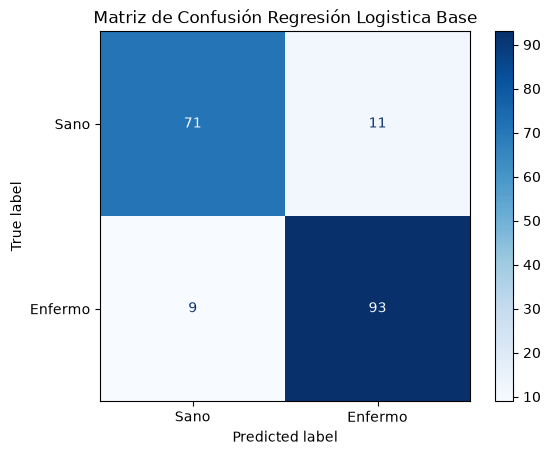

In [17]:
#Equivalencias de las clase objetivo (0 y 1 respectivamente)
clases = ['Sano', 'Enfermo']

# Metricas para evaluar los modelos
metricas = ['accuracy', 'precision', 'recall','f1','roc_auc']
# Calculando las predicciones y la matriz de confusión
y_pred = reglog_base.predict(X_test)

# Imprimiendo el reporte de clasificación
print(classification_report(y_test, y_pred,  target_names=clases))

#Construyendo matriz de confusión
ConfusionMatrixDisplay.from_predictions(y_test, y_pred, display_labels=clases, cmap='Blues', )

# Agregando titulo a la gráfica
plt.title('Matriz de Confusión Regresión Logistica Base')
plt.show()

In [18]:
# Hiperparametros a utilizar
rejilla_reglog = {
    "modelo__C":            [0.001, 0.01, 0.1, 1, 10, 100],
    "modelo__l1_ratio":     [0, 0.5, 1],             # 0 = L2 · 0.5 = mezcla · 1 = L1
    "modelo__class_weight": [None, "balanced"],
}

In [19]:
mejores_modelos = {}

for metrica in metricas:
    busqueda = GridSearchCV(reglog_base, rejilla_reglog, scoring=metrica, cv=5, n_jobs=-1)
    busqueda.fit(X_train, y_train)
    mejores_modelos[metrica] = busqueda.best_estimator_
    print(f'{metrica} >> {round(busqueda.best_score_, 3)}, {busqueda.best_params_}')

accuracy >> 0.856, {'modelo__C': 0.1, 'modelo__class_weight': None, 'modelo__l1_ratio': 0.5}
precision >> 0.87, {'modelo__C': 10, 'modelo__class_weight': 'balanced', 'modelo__l1_ratio': 0}
recall >> 1.0, {'modelo__C': 0.001, 'modelo__class_weight': None, 'modelo__l1_ratio': 0.5}
f1 >> 0.872, {'modelo__C': 0.1, 'modelo__class_weight': None, 'modelo__l1_ratio': 0.5}
roc_auc >> 0.915, {'modelo__C': 1, 'modelo__class_weight': 'balanced', 'modelo__l1_ratio': 1}


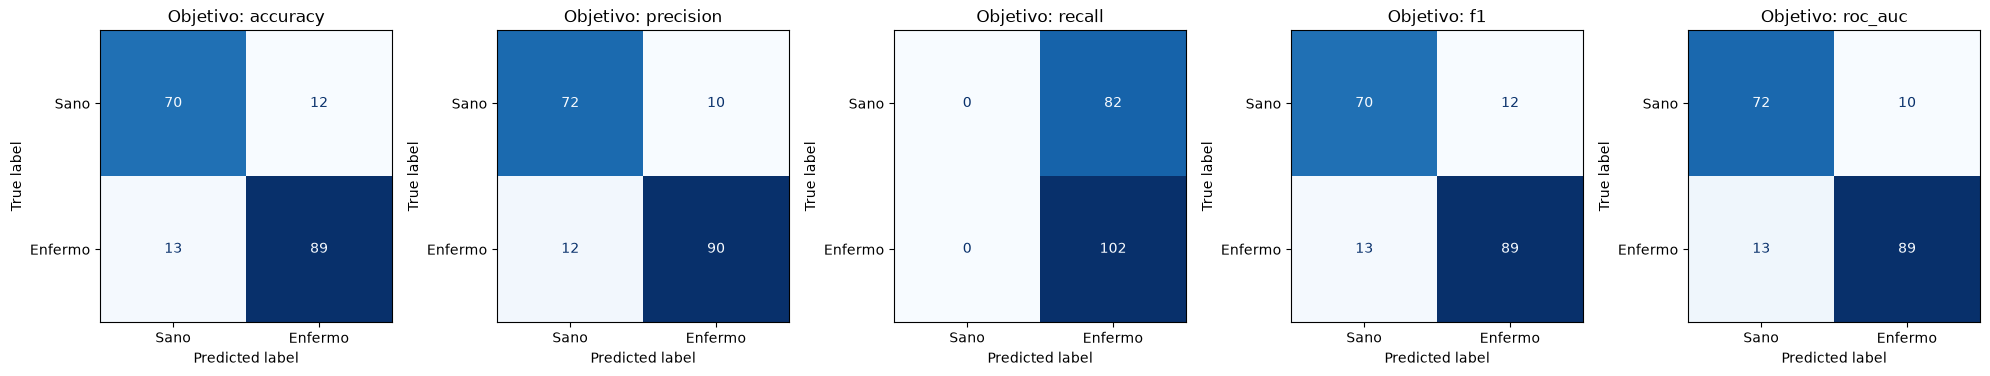

In [20]:
#Mostrando todas las matrices de confucion

fig, ejes = plt.subplots(1, 5, figsize=(20, 4))      # 1 fila con 5 recuadros

for eje, metrica in zip(ejes, metricas):
    y_pred = mejores_modelos[metrica].predict(X_test)
    ConfusionMatrixDisplay.from_predictions(y_test, y_pred, display_labels=clases,
                                            cmap="Blues", colorbar=False, ax=eje)
    eje.set_title(f"Objetivo: {metrica}")

plt.tight_layout()
plt.show()

# Maquinas de Vectores de Soporte (SVM)

In [21]:
from sklearn.naive_bayes import GaussianNB

#Pipeline
nb_base = Pipeline([
    ("prep",  prep),
    ("modelo", GaussianNB())
])

# Ajustando modelo con valores por defecto
nb_base.fit(X_train, y_train)



,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('prep', ...), ('modelo', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"classes_ classes_: ndarray of shape (n_classes,)The classes labels. Only exist if the last step of the pipeline is aclassifier.","ndarray[int64](2,)","[0,1]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](15,)","['Age','RestingBP','Cholesterol',...,'ExerciseAngina_Y','ST_Slope_Flat', 'ST_Slope_Up']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,15
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remai

              precision    recall  f1-score   support

        Sano       0.84      0.89      0.86        82
     Enfermo       0.91      0.86      0.88       102

    accuracy                           0.88       184
   macro avg       0.87      0.88      0.87       184
weighted avg       0.88      0.88      0.88       184



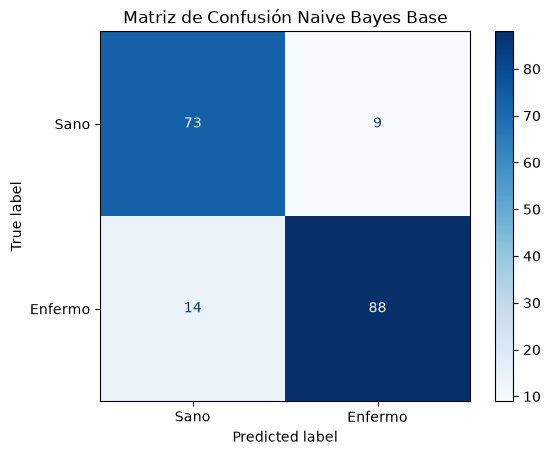

In [22]:
# Calculando las predicciones y la matriz de confusión
y_pred = nb_base.predict(X_test)

# Imprimiendo el reporte de clasificación
print(classification_report(y_test, y_pred,  target_names=clases))

#Construyendo matriz de confusión
ConfusionMatrixDisplay.from_predictions(y_test, y_pred, display_labels=clases, cmap='Blues', )

# Agregando titulo a la gráfica
plt.title('Matriz de Confusión Naive Bayes Base')
plt.show()


In [23]:
from sklearn.preprocessing import PowerTransformer
rejilla_nb = {
    "modelo__priors":        [None, [0.7, 0.3], [0.3, 0.7]],
    "modelo__var_smoothing": [1e-9, 1e-6, 1e-3, 0.01, 0.1, 1, 10],
}

In [24]:
mejores_modelos = {}

for metrica in metricas:
    busqueda = GridSearchCV(nb_base, rejilla_nb, scoring=metrica, cv=5, n_jobs=-1)
    busqueda.fit(X_train, y_train)
    mejores_modelos[metrica] = busqueda.best_estimator_
    print(f'{metrica} >> {round(busqueda.best_score_, 3)}, {busqueda.best_params_}')

accuracy >> 0.854, {'modelo__priors': [0.3, 0.7], 'modelo__var_smoothing': 0.01}
precision >> 0.898, {'modelo__priors': [0.7, 0.3], 'modelo__var_smoothing': 1}
recall >> 1.0, {'modelo__priors': [0.3, 0.7], 'modelo__var_smoothing': 10}
f1 >> 0.871, {'modelo__priors': [0.3, 0.7], 'modelo__var_smoothing': 0.01}
roc_auc >> 0.914, {'modelo__priors': None, 'modelo__var_smoothing': 0.01}


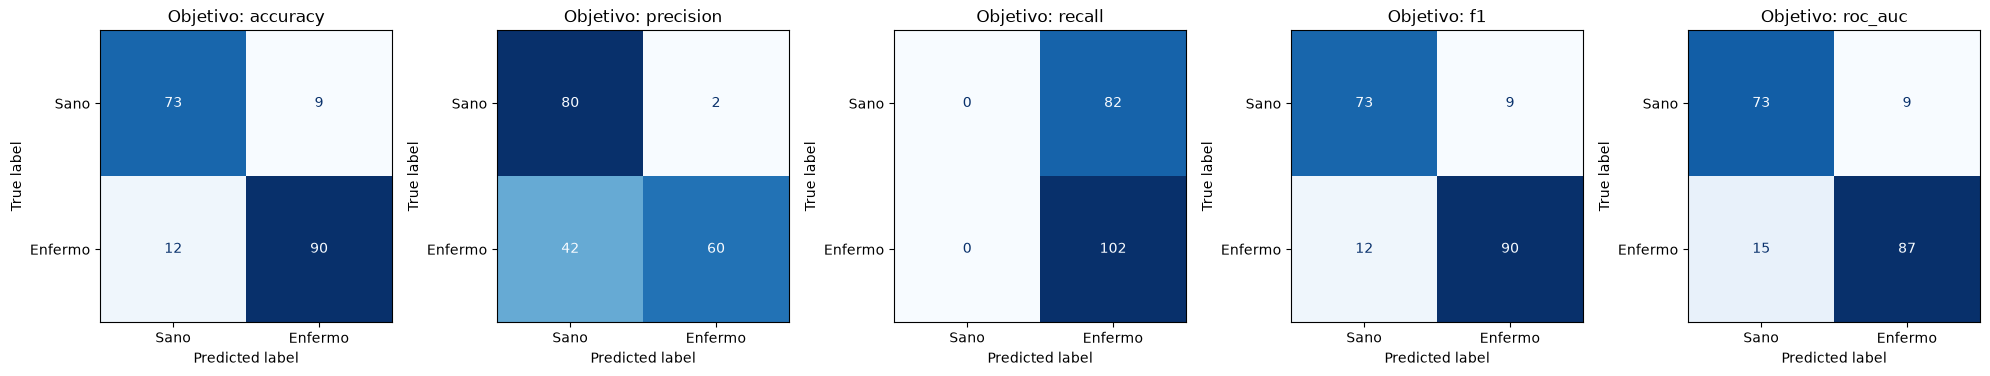

In [25]:
# Mostrando todas las matrices de confusión 

fig, ejes = plt.subplots(1, 5, figsize=(20, 4))      # 1 fila con 5 recuadros

for eje, metrica in zip(ejes, metricas):
    y_pred = mejores_modelos[metrica].predict(X_test)
    ConfusionMatrixDisplay.from_predictions(y_test, y_pred, display_labels=clases,
                                            cmap="Blues", colorbar=False, ax=eje)
    eje.set_title(f"Objetivo: {metrica}")

plt.tight_layout()
plt.show()

# Conclusión
En conclusión, al probar diferentes métodos de Machine Learning se pudo observar que el modelo Naive Bayes fue el que obtuvo mejores resultados. Después de ajustar sus hiperparámetros, utilizando priors: [0.3, 0.7] y var_smoothing: 0.01
